# Imports and Defs

In [3]:
import time as _time

import numpy as _np
import matplotlib.pyplot as plt

from siriuspy.oscilloscope import Keysight, Scopes, ScopeSignals, WaveformAcquisition

from siriuspy.currinfo import LICurrInfoApp

def plot_waveforms(wfms):
    for chan in wfms:
        plt.plot(1e6*wfms[chan][0], 1e3*wfms[chan][1], label=chan)
    plt.xlabel('time [µs]')
    plt.ylabel('Voltage [mV]')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

# Test WaveformAcquisition

In [4]:
keysight = Keysight(scope=LICurrInfoApp.OSC)
acq = WaveformAcquisition(keysight)

In [5]:
status_ok, stat, wfms = acq.acquire(acq_wfms=True, acq_meas=True, print_time=True)

CHAN1: 0.146 s
CHAN2: 0.147 s
CHAN3: 0.150 s
CHAN4: 0.182 s
--------------------------
TOTAL: 1.826 s


In [6]:
stat

['Charge-TB-ICT2',
 '3.8438E-09',
 '0',
 '3.8438E-09',
 '3.8438E-09',
 '3.8438E-09',
 '0.0E+00',
 '1E+00',
 'Charge-TB-ICT1',
 '2.9846E-09',
 '0',
 '2.9846E-09',
 '2.9846E-09',
 '2.9846E-09',
 '0.0E+00',
 '1E+00',
 'Charge-LI-ICT2',
 '2.8231E-09',
 '0',
 '2.8231E-09',
 '2.8231E-09',
 '2.8231E-09',
 '0.0E+00',
 '1E+00',
 'Charge-LI-ICT1',
 '3.0926E-09',
 '0',
 '3.0926E-09',
 '3.0926E-09',
 '3.0926E-09',
 '0.0E+00',
 '1E+00\n']

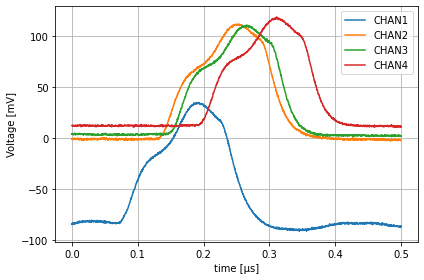

In [7]:
plot_waveforms(wfms)

In [8]:
t0 = _time.time(); p = acq.process_waveform(wfms['CHAN1']); t1 = _time.time(); print(t1-t0)

0.0025653839111328125


In [12]:
acq

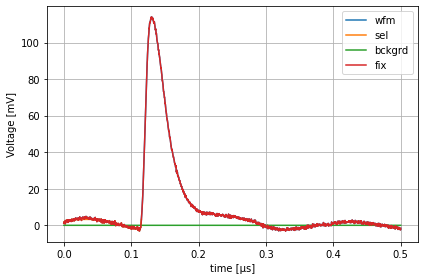

charge   : 0.967 nC
timepeak : 0.130 µs
offset   : 0.00 mV
slope    : 0.00 mV/µs

charges [nC]: 0.967 0.427 0.721 1.485


In [28]:
perc, order = 0.02, 0
# process_aparms = perc, order
process_params = tuple()
func = process_waveform_0

params = analyse_waveform(func, wfms['CHAN1'], process_params, True)
charge1, tim1, val1, sel1, val1_fit, tim1_fix, val1_fix, tim1_peak, pcoeffs1 = params
params = analyse_waveform(func, wfms['CHAN2'], process_params, True)
charge2, tim2, val2, sel2, val2_fit, tim2_fix, val2_fix, tim2_peak, pcoeffs2 = params
params = analyse_waveform(func, wfms['CHAN3'], process_params, True)
charge3, tim3, val3, sel3, val3_fit, tim3_fix, val3_fix, tim3_peak, pcoeffs3 = params
params = analyse_waveform(func, wfms['CHAN4'], process_params, True)
charge4, tim4, val4, sel4, val4_fit, tim4_fix, val4_fix, tim4_peak, pcoeffs4 = params

print()
print(f'charges [nC]: {charge1:.3f} {charge2:.3f} {charge3:.3f} {charge4:.3f}')

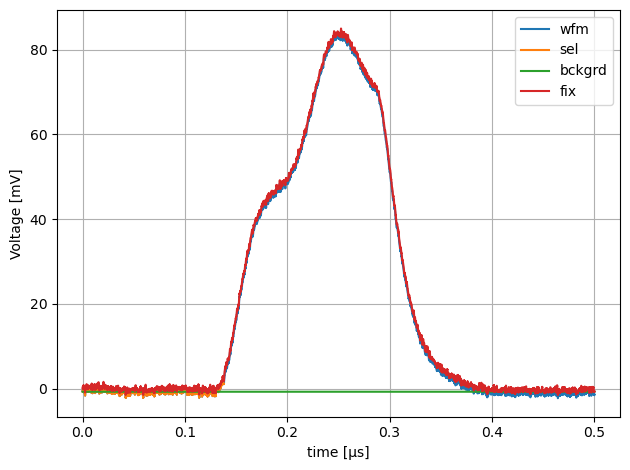

charge : 2.051 nC
timepeak : 0.253 µs
offset : -0.75 mV


In [26]:
perc = 0.02
order = 0
process_aparms = perc, order
# process_aparms = tuple()
params = analyse_waveform(wfms['CHAN2'], process_aparms)
charge2, tim2, val2, sel2, val2_fit, tim2_fix, val2_fix, tim2_peak, pcoeffs2 = params

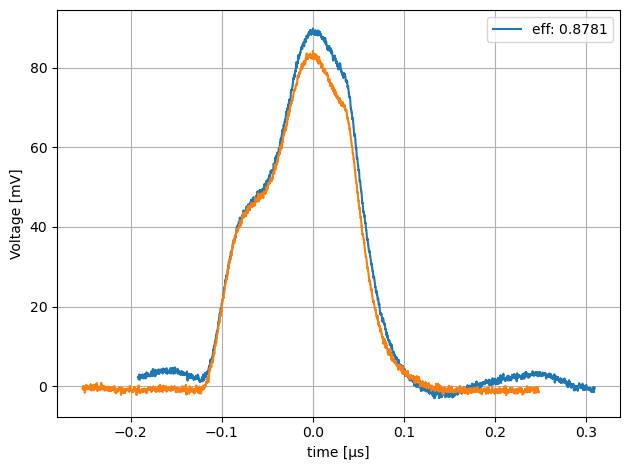

In [22]:
plt.plot(1e6*(tim1_fix - tim1_peak), 1e3*val1_fix, label=f'eff: {charge2/charge1:.4f}')
plt.plot(1e6*(tim2_fix - tim2_peak), 1e3*val2_fix)
plt.xlabel('time [µs]')
plt.ylabel('Voltage [mV]')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

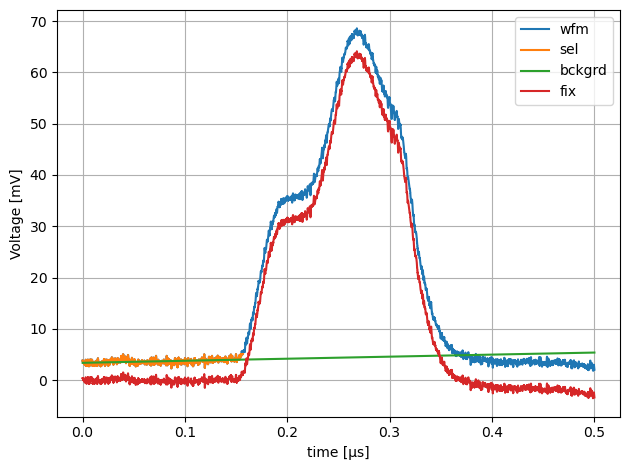

charge : 1.351 nC
offset : 3.40 mV
slope  : 3.99 mV/µs


In [15]:
perc = 0.02
process_aparms = perc
params = analyse_waveform(wfms['CHAN3'], process_aparms)
charge3, tim3, val3, sel3, val3_fit, val3_fix, max_idx3, pcoeffs3 = params

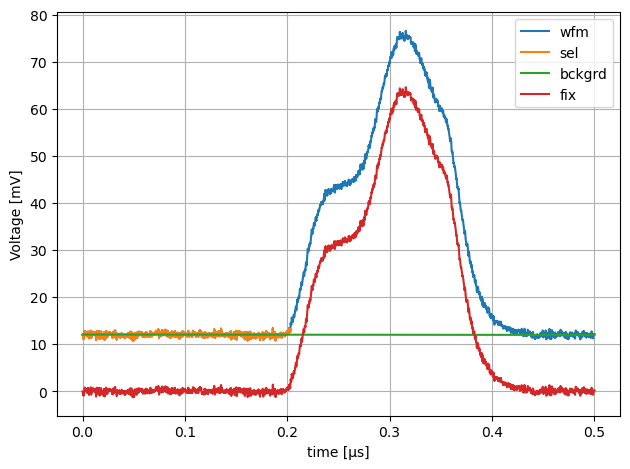

charge : 1.414 nC
offset : 12.04 mV
slope  : -0.16 mV/µs


In [16]:
perc = 0.02
process_aparms = perc
params = analyse_waveform(wfms['CHAN4'], process_aparms)
charge4, tim4, val4, sel4, val4_fit, val4_fix, max_idx4, pcoeffs4 = params

# Test LICurrInfoApp

In [7]:
currinfo = LICurrInfoApp()

In [8]:
currinfo.get_measurement()

In [6]:
currinfo.stat

['Charge-TB-ICT2',
 '2.9962E-09',
 '0',
 '2.9962E-09',
 '2.9962E-09',
 '2.9962E-09',
 '0.0E+00',
 '1E+00',
 'Charge-TB-ICT1',
 '2.1556E-09',
 '0',
 '2.1556E-09',
 '2.1556E-09',
 '2.1556E-09',
 '0.0E+00',
 '1E+00',
 'Charge-LI-ICT2',
 '1.92096E-09',
 '0',
 '1.92096E-09',
 '1.92096E-09',
 '1.92096E-09',
 '0.0E+00',
 '1E+00',
 'Charge-LI-ICT1',
 '2.1396E-09',
 '0',
 '2.1396E-09',
 '2.1396E-09',
 '2.1396E-09',
 '0.0E+00',
 '1E+00\n']

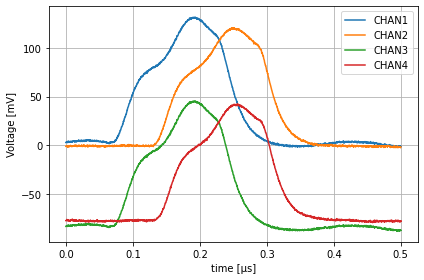

In [9]:
wfms = currinfo.wfms
plot_waveforms(wfms)

In [10]:
wfm1 = currinfo.wfms['CHAN1']
wfm2 = currinfo.wfms['CHAN2']
wfm3 = currinfo.wfms['CHAN3']
wfm4 = currinfo.wfms['CHAN4']

p1m1 = currinfo.osc_obj.process_waveform(wfm1, 'scope')
p2m1 = currinfo.osc_obj.process_waveform(wfm2, 'scope')
p3m1 = currinfo.osc_obj.process_waveform(wfm3, 'scope')
p4m1 = currinfo.osc_obj.process_waveform(wfm4, 'scope')

p1m2 = currinfo.osc_obj.process_waveform(wfm1, 'baseline2')
p2m2 = currinfo.osc_obj.process_waveform(wfm2, 'baseline2')
p3m2 = currinfo.osc_obj.process_waveform(wfm3, 'baseline2')
p4m2 = currinfo.osc_obj.process_waveform(wfm4, 'baseline2')

TypeError: expected non-empty vector for x

In [ ]:
 # selection
        indcs = _np.arange(len(val))
        sel = (indcs < perc * len(val)) & ((indcs > (1-perc) * len(val)))

In [10]:
print(1e9*p1m1[0]/5)
print(1e9*p2m1[0]/5)
print(1e9*p3m1[0]/5)
print(1e9*p4m1[0]/5)

0.08001311399999944
0.09809512532800062
8.582996807047731
7.782279401464818


In [11]:
print(1e9*p1m2[0]/5)
print(1e9*p2m2[0]/5)
print(1e9*p3m2[0]/5)
print(1e9*p4m2[0]/5)

TypeError: 'NoneType' object is not subscriptable